# Notebook 04 — Optional extensions (advanced)

> **Optional / advanced.** Nothing here is needed for the competition or the
> debrief. It's for groups who finish early and want to explore strategy design
> more deeply. Every section reuses the engine you already have — no new
> Bayesian-optimization code, no debugging BO internals.

The sections are independent — jump to whichever interests you:

1. **Custom scalarization schedule** — change your preference weights round by round.
2. **Explore → exploit schedule** — spend early budget learning, then cash in.
3. **Alternative projection rules** — `nearest` vs `diverse_nearest`.
4. **Information-theoretic acquisitions** — a conceptual look (discussion + one run).

Each section runs a full campaign with `competition.run_campaign` and compares it
to a baseline.

## Setup

In [1]:
import matplotlib.pyplot as plt
import torch

from mobo_lab import competition, config, seed
from mobo_lab.acquisitions import format_scalarized_name

seed.set_all_seeds(config.SEED)
N_ROUNDS = config.N_ROUNDS


def auc_and_final(history):
    return history["auc_hv"], history["final_hv"], history["n_nondominated_selected"]


def compare(rows):
    """Print a small comparison table: rows of (label, history)."""
    print(f"{'strategy':<28}{'AUC-HV':>9}{'finalHV':>9}{'nondom':>8}")
    print("-" * 54)
    for label, h in rows:
        a, f, nd = auc_and_final(h)
        print(f"{label:<28}{a:>9.4f}{f:>9.4f}{nd:>8d}")


def selected_objectives(history):
    """Observed objectives of the points this campaign *added* (excludes the initial design)."""
    Y = torch.tensor(history["final_Y"], dtype=torch.double)
    return Y[history["n_initial"]:]


def lean(history):
    """Mean (objective 1 - objective 2) of the selected points: which side of the front."""
    sel = selected_objectives(history)
    return float((sel[:, 0] - sel[:, 1]).mean())

## 1. A fixed weight commits you to a side of the front

A fixed scalarization encodes one preference for the whole campaign. Because the
true front is **concave** (a recessed middle between a binding-favoring lobe and a
stability-favoring lobe — you'll see this in the Notebook 03 reveal), the *weight*
you choose steers **which side of the front** your batches land on.

We run three campaigns from the same start:

- **binding** — fixed `scalarized_0.8_0.2` every round (favor objective 1),
- **stability** — fixed `scalarized_0.2_0.8` every round (favor objective 2),
- **rotating** — alternate the two each round, so the preference *changes over time*.

To see the effect we measure each campaign's **lean** = mean(objective 1 −
objective 2) over its selected points: positive = it leaned to the binding side,
negative = the stability side, near zero = balanced/both.

In [2]:
binding = [{"scalarized_0.8_0.2": config.BATCH_SIZE}] * N_ROUNDS
stability = [{"scalarized_0.2_0.8": config.BATCH_SIZE}] * N_ROUNDS
rotating = [{format_scalarized_name(w): config.BATCH_SIZE} for w in [[0.8, 0.2], [0.2, 0.8]] * 3]

h_binding = competition.run_campaign(binding, "fixed_binding")
h_stability = competition.run_campaign(stability, "fixed_stability")
h_rotating = competition.run_campaign(rotating, "rotating_weights")

print(f"{'strategy':<22}{'lean (o1-o2)':>13}{'AUC-HV':>9}{'finalHV':>9}")
print("-" * 53)
for label, h in [("binding 0.8/0.2", h_binding), ("stability 0.2/0.8", h_stability),
                 ("rotating", h_rotating)]:
    a, f, _ = auc_and_final(h)
    print(f"{label:<22}{lean(h):>13.3f}{a:>9.4f}{f:>9.4f}")

strategy               lean (o1-o2)   AUC-HV  finalHV
-----------------------------------------------------
binding 0.8/0.2               0.024   0.8242   0.9518
stability 0.2/0.8            -0.227   0.8442   1.0087
rotating                     -0.038   0.8321   1.0087


The two fixed weights pull to **opposite sides** (binding leans positive, stability
leans strongly negative); the rotating schedule lands **in between**, visiting both.
See it in objective space — existing measurements in gray, each campaign's picks in
red:

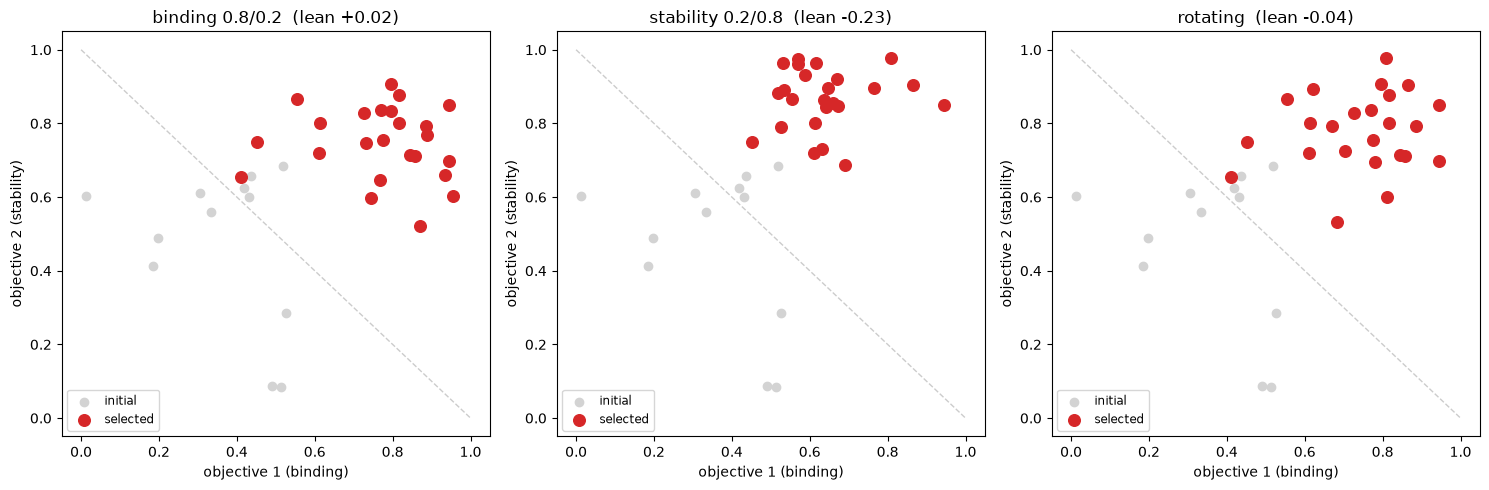

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, h) in zip(
    axes,
    [("binding 0.8/0.2", h_binding), ("stability 0.2/0.8", h_stability), ("rotating", h_rotating)],
):
    full = torch.tensor(h["final_Y"], dtype=torch.double)
    n0 = h["n_initial"]
    ax.scatter(full[:n0, 0], full[:n0, 1], color="lightgray", label="initial")
    ax.scatter(full[n0:, 0], full[n0:, 1], color="tab:red", s=70, label="selected")
    ax.plot([0, 1], [1, 0], color="0.8", linestyle="--", linewidth=1)  # balanced diagonal
    ax.set_title(f"{label}  (lean {lean(h):+.2f})")
    ax.set_xlabel("objective 1 (binding)")
    ax.set_ylabel("objective 2 (stability)")
    ax.legend(loc="lower left", fontsize="small")
fig.tight_layout();

**Teaching point:** the scalarization *weight* reliably steers **which side** of a
concave front you reach — a fixed weight commits you to one side for the whole
campaign, while changing the weight over rounds lets you visit both. (Which
strategy wins on AUC-HV is seed-dependent and *not* the lesson here — the robust,
repeatable effect is the **lean**, i.e. *where* the picks land.)

## 2. Explore → exploit schedule

Spend early rounds **exploring** (random + ParEGO sample many trade-offs), then
switch to **exploiting** (NEHVI sharpens the front). Compare to playing NEHVI from
the start.

strategy                       AUC-HV  finalHV  nondom
------------------------------------------------------
explore -> exploit             0.8325   1.0356       6
all NEHVI                      0.8588   1.0231       5


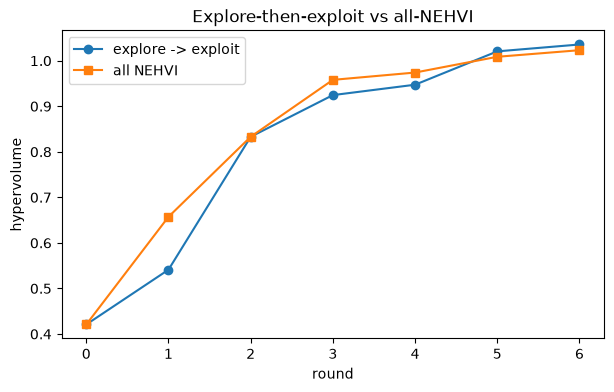

In [4]:
explore_exploit = [
    {"random": 2, "parego": 2},
    {"parego": 4},
    {"nehvi": 2, "parego": 2},
    {"nehvi": 4},
    {"nehvi": 4},
    {"nehvi": 4},
]
assert len(explore_exploit) == N_ROUNDS

all_nehvi = [{"nehvi": config.BATCH_SIZE}] * N_ROUNDS

h_ee = competition.run_campaign(explore_exploit, "explore_then_exploit")
h_nehvi = competition.run_campaign(all_nehvi, "all_nehvi")

compare([("explore -> exploit", h_ee), ("all NEHVI", h_nehvi)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h_ee["hv_history"], marker="o", label="explore -> exploit")
ax.plot(h_nehvi["hv_history"], marker="s", label="all NEHVI")
ax.set_xlabel("round")
ax.set_ylabel("hypervolume")
ax.set_title("Explore-then-exploit vs all-NEHVI")
ax.legend();

**Teaching point:** exploration spends hypervolume *now* to find regions that pay
off *later*. Whether it wins depends on how hidden the good regions are.

## 3. Alternative projection rules

On the **continuous** path, the acquisition optimizer proposes a point in the
design box and we snap it to a real sequence. `nearest` snaps to the closest
unmeasured sequence; `diverse_nearest` also pushes the batch apart, so a clump of
similar proposals fans out. We run the *same* plan both ways (continuous path, so
projection actually matters) and compare.

In [5]:
projection_plan = [{"nehvi": config.BATCH_SIZE}] * N_ROUNDS

h_nearest = competition.run_campaign(
    projection_plan, "proj_nearest", projection_method="nearest", optimize="continuous"
)
h_diverse = competition.run_campaign(
    projection_plan, "proj_diverse", projection_method="diverse_nearest", optimize="continuous"
)

compare([("nearest", h_nearest), ("diverse_nearest", h_diverse)])

strategy                       AUC-HV  finalHV  nondom
------------------------------------------------------
nearest                        0.8388   1.0303       4
diverse_nearest                0.7984   0.9433       4


**Teaching point:** projection decides which designs actually get tested. A
diversity-aware rule can broaden coverage of the front when the optimizer keeps
proposing similar points. (Stretch ideas: cluster-aware projection, or a
similarity penalty that discourages near-duplicate sequences.)

## 4. Information-theoretic acquisitions (conceptual)

The core lab scores candidates by *expected hypervolume improvement*. An
alternative family scores by **information gain** — pick the antibody whose
measurement would most reduce the model's uncertainty about the Pareto front
(e.g. PES / MES / JES). These are powerful but heavier to set up and tune, so they
are **beyond the core lab**.

Our `uncertainty` card is a lightweight stand-in for the *spirit* of these
methods: it spends the batch where the model is least sure, ignoring the mean.
Here is a single round of it versus NEHVI, just to see the contrast — not
something to debug.

In [6]:
uncertainty_plan = [{"uncertainty": config.BATCH_SIZE}] + [{"nehvi": config.BATCH_SIZE}] * (N_ROUNDS - 1)
h_unc = competition.run_campaign(uncertainty_plan, "uncertainty_first")
compare([("uncertainty then NEHVI", h_unc), ("all NEHVI", h_nehvi)])

strategy                       AUC-HV  finalHV  nondom
------------------------------------------------------
uncertainty then NEHVI         0.9625   1.0356       7
all NEHVI                      0.8588   1.0231       5


**Teaching point:** pure uncertainty-seeking explores aggressively but ignores
whether a region is actually *good*; real information-theoretic methods target
uncertainty *about the Pareto front specifically*, which is why they can be worth
the extra machinery.

---
That's the menu. The big idea across all four: the closed loop stays the same —
you are only changing *how each batch is chosen*.